# IT Security Agent - Week 3
### The full agent: scan input -> find vulnerabilities -> explain -> report

**Course:** AI & Ethics - IT Security Agent project

The problem statement: use NVD vulnerability data to build an agent that
scans container images or SBOMs for vulnerabilities. This notebook runs
that agent end-to-end for the first time: a component list goes in, a
triaged and explained vulnerability report comes out.

All the logic now lives in a real Python package, `it_security_agent/`
(18 modules, 69 tests, 94% coverage) - this notebook just wires it
together.

## Weekly Status

### What did we do this week?
Moved everything out of notebook code into the `it_security_agent/`
package and connected it into one pipeline:

- **Three input paths**, one component format: lockfiles (`repo_scan.py`),
  SBOMs (`sbom.py`), and container images (`image_scan.py`, via Syft).
- **A local NVD cache** (SQLite): sync once up front, then every lookup
  during a scan is local. No more live NVD calls per package (Week 2's
  main bottleneck).
- **Automatic training labels** (`labeling.py`): instead of Week 2's 28
  hand-labeled pairs, a vendor match now counts as "real" if its CPE
  entry links to the same website as the package's registry page.
- **Two models compared** (`model.py`): logistic regression vs. random
  forest, scored with Week 2's risk metric; only the winner is saved.
- **SHAP explanations** (`explain.py`) for any match the agent isn't
  sure about.
- **A triage policy** (`agent.py`): every match ends up `confirmed`,
  `escalated` (actively exploited), `review_queue` (a human should
  look), or `rejected`.
- **Reports** (`report.py`): JSON + HTML output.

### What were our challenges?
- **NVD's "recently modified" filter is misleading.** A 30-day window
  returned 347,572 CVEs - basically the whole catalog, because NVD
  re-touched almost every record about a month ago. A 14-day window
  (~7,700 CVEs) keeps the sync fast, so that's what we use.
- **One CPE Dictionary request hung for 20+ minutes.** That endpoint has
  no retry or pacing built in. We added our own timeout, skip-on-failure,
  and a hard time budget (Section 2a), and scoped the live-network
  sections to 32 components so a presentation run finishes reliably.
- **Syft/Docker aren't installed here**, so the container-image path is
  unit-tested (with a mocked Syft) but not run live in this notebook.
- **The package isn't pip-installed yet** - the first code cell adds the
  repo root to `sys.path` as a workaround.

### What are our next steps?
- Package `it_security_agent` properly (drop the `sys.path` workaround).
- Grow the training set beyond the registry-overlap heuristic.
- Run the container-image path live once Syft/Docker are available.
- Surface the JSON/HTML report somewhere beyond this notebook.

---
## 1. Input: one component list from all input paths

The agent doesn't care where a component came from - lockfile, SBOM, or
container image all become the same **(name, version, ecosystem, purl)**
records, the format we've used since Week 1.

(The package isn't pip-installed yet, so the first cell adds the repo
root to `sys.path` - see Weekly Status.)

In [1]:
import json
import sys
import time
import datetime
from pathlib import Path

sys.path.insert(0, "..")  # it_security_agent isn't pip-installed; see Weekly Status

import pandas as pd
import requests
import shap
from dotenv import load_dotenv

from it_security_agent import (
    repo_scan, sbom, nvd_cache, cpe_dictionary, kev, labeling, model, explain, agent, report,
)

load_dotenv(Path("..") / ".env")
import os
NVD_API_KEY = os.environ.get("NVD_API_KEY")
REQUEST_SPACING_SECONDS = 1 if NVD_API_KEY else 6
print("Using NVD API key: yes" if NVD_API_KEY else "Using NVD API key: no (unauthenticated, slower)")

Using NVD API key: yes


### 1a. This project's own `uv.lock`
Same real input as Week 2, now parsed by the package
(`repo_scan.parse_uv_lock`) instead of inline notebook code.

In [2]:
components = repo_scan.parse_uv_lock(Path("..") / "uv.lock")
print(f"{len(components)} pinned PyPI packages found in uv.lock")
pd.DataFrame([{"name": c.name, "version": c.version, "ecosystem": c.ecosystem, "purl": c.purl}
              for c in components]).head()

158 pinned PyPI packages found in uv.lock


,name,version,ecosystem,purl
0,annotated-doc,0.0.4,PyPI,pkg:pypi/annotated-doc@0.0.4
1,annotated-types,0.7.0,PyPI,pkg:pypi/annotated-types@0.7.0
2,anyio,4.14.1,PyPI,pkg:pypi/anyio@4.14.1
3,appnope,0.1.4,PyPI,pkg:pypi/appnope@0.1.4
4,argon2-cffi,25.1.0,PyPI,pkg:pypi/argon2-cffi@25.1.0


### 1b. SBOM input: CycloneDX
A second input path: a small but real CycloneDX SBOM (the test fixture
from `tests/`), parsed by `sbom.parse_cyclonedx`.

### 1c. Container image input: not run here
`image_scan.scan_image("python:3.11-slim")` would be the third path, but
Syft and Docker aren't available in this environment, so the call is
commented out rather than faked. The module has its own unit tests with a
mocked Syft.

In [3]:
sbom_data = json.loads((Path("..") / "tests" / "fixtures" / "sample_cyclonedx.json").read_text())
components += sbom.parse_cyclonedx(sbom_data)
# components += image_scan.scan_image("python:3.11-slim")  # Syft/Docker not available here

print(f"Unified component list: {len(components)} components "
      f"({sum(c.ecosystem == 'PyPI' for c in components)} PyPI, "
      f"{sum(c.ecosystem == 'npm' for c in components)} npm)")

Unified component list: 160 components (159 PyPI, 1 npm)


### 1d. Keeping the live run small
Three sections below (2a, 3, 5) make one web request per component. At
139 components that's hundreds of sequential requests - and one hung
request already stalled a full-scale run for 20+ minutes (see Weekly
Status). For a run that has to finish in front of an audience, we scope
those live sections to 32 components. The package code itself has no such
limit - this is a notebook choice, not a code path.

In [4]:
LIVE_SUBSET_SIZE = 30
sbom_components = [c for c in components if c.source.startswith("SBOM")]
live_components = components[:LIVE_SUBSET_SIZE] + sbom_components

# Week 2's four name-collision false positives (babel, jupyter, json5, jsonpointer -
# see the Section 9 weakness audit below) are added explicitly so Section 3's
# auto-labeling trains on them too, not just Section 9's dedicated regression check.
# babel already falls in the first 30 alphabetically; the other three don't.
COLLISION_REGRESSION_NAMES = {"babel", "jupyter", "json5", "jsonpointer"}
already_included = {c.name for c in live_components}
added_for_regression = [c for c in components
                         if c.name in COLLISION_REGRESSION_NAMES and c.name not in already_included]
live_components += added_for_regression

print(f"scoping live network stages (2a, 3, 5) to {len(live_components)}/{len(components)} components "
      f"({LIVE_SUBSET_SIZE} from uv.lock + {len(sbom_components)} from the CycloneDX SBOM + "
      f"{len(added_for_regression)} added for the Section 9 collision regression check)")

scoping live network stages (2a, 3, 5) to 35/160 components (30 from uv.lock + 2 from the CycloneDX SBOM + 3 added for the Section 9 collision regression check)


---
## 2. Sync NVD + CISA KEV once, then work locally

Week 2 queried NVD live for every package, every scan - minutes per run.
Now we sync once into a local SQLite database (`nvd_cache.py`), and every
lookup during the scan is local.

We sync only CVEs modified in the last **14 days** instead of the full
catalog: NVD re-touched nearly every CVE about a month ago, so a 30-day
window would have been a full backfill in disguise (347,572 results,
vs. 7,763 at 14 days). CISA's KEV list (CVEs actively exploited in the
wild) is small, so we always pull all of it.

In [5]:
conn = nvd_cache.get_connection()

t0 = time.time()
since = datetime.datetime.utcnow() - datetime.timedelta(days=14)
n_cves = nvd_cache.sync_incremental(since=since, conn=conn)
print(f"synced {n_cves} CVEs modified in the last 14 days ({time.time()-t0:.1f}s)")

t0 = time.time()
n_kev = kev.refresh(conn=conn)
print(f"refreshed {n_kev} CISA KEV (Known Exploited Vulnerabilities) entries ({time.time()-t0:.1f}s)")

synced 8913 CVEs modified in the last 14 days (252.9s)


refreshed 1647 CISA KEV (Known Exploited Vulnerabilities) entries (1.9s)


### 2a. Pre-warming the CPE Dictionary cache
Both training and matching look up each package name in NVD's CPE
Dictionary. Unlike the CVE endpoint, that API has no retry or pacing
built in - our first attempt stalled for 20+ minutes on a single stuck
request. So this cell does all the lookups up front, with a 20s timeout
per request, skipping failures instead of blocking on them, and giving up
after a hard time budget.

A name that doesn't get cached simply produces no vendor candidates
later - the pipeline already treats that as "no match", not an error.

In [6]:
names = sorted({c.name for c in live_components})
print(f"{len(names)} distinct package names to pre-warm")


def _bounded_get(*a, **k):
    k["timeout"] = 20  # much tighter than cpe_dictionary's own 90s default
    return requests.get(*a, **k)


PREWARM_BUDGET_SECONDS = 120
t0 = time.time()
failures = []
for i, name in enumerate(names, 1):
    if time.time() - t0 > PREWARM_BUDGET_SECONDS:
        print(f"  stopping pre-warm early at {i-1}/{len(names)} names "
              f"({time.time()-t0:.0f}s budget reached) - the rest simply won't "
              f"have CPE candidates this run")
        break
    try:
        cpe_dictionary.search(name, conn=conn, api_key=NVD_API_KEY, get_fn=_bounded_get)
    except Exception as e:
        failures.append((name, str(e)))
    if i % 20 == 0 or i == len(names):
        print(f"  {i}/{len(names)} processed ({time.time()-t0:.1f}s elapsed, {len(failures)} failures)")
    time.sleep(REQUEST_SPACING_SECONDS)
print(f"CPE Dictionary pre-warm done ({time.time()-t0:.1f}s), {len(failures)} request failures")

35 distinct package names to pre-warm


  20/35 processed (21.1s elapsed, 0 failures)


  35/35 processed (39.6s elapsed, 0 failures)


CPE Dictionary pre-warm done (40.6s), 0 request failures


---
## 3. Train two models, keep the better one

Week 2 hand-labeled 28 (package, vendor) pairs. Now `labeling.build_dataset`
labels thousands automatically: a vendor candidate counts as a real match
if its CPE entry's reference URL shares a domain with the package's own
registry homepage/repo. That signal is used **only as the label**, never
as a model feature (regression-tested), so the model can't cheat.

`model.train_and_compare` then trains a logistic regression and a random
forest, scores both with Week 2's risk metric (a missed real
vulnerability costs 10x a false alarm), and saves only the winner.

In [7]:
t0 = time.time()
dataset = labeling.build_dataset(live_components, conn=conn)
print(f"training dataset: {len(dataset)} labeled (package, vendor-candidate) rows "
      f"({time.time()-t0:.1f}s)")
if len(dataset):
    print(dataset["label_real_match"].value_counts().rename("count").to_string())
dataset.head()

training dataset: 17080 labeled (package, vendor-candidate) rows (7.2s)
label_real_match
False    15092
True      1988


,package,ecosystem,vendor,vendor_equals_package,name_similarity,py_keyword_score,js_keyword_score,keyword_alignment,ecosystem_pypi,osv_corroborated,label_real_match
0,arrow,PyPI,cisco,0,0.666667,0,0,0,1,0,False
1,arrow,PyPI,fujitsu,0,0.500000,0,0,0,1,0,False
2,arrow,PyPI,fujitsu,0,0.400000,0,0,0,1,0,False
3,arrow,PyPI,fujitsu,0,0.454545,0,0,0,1,0,False
4,arrow,PyPI,arrow-kt,0,1.000000,0,0,0,1,0,False


In [8]:
training_result = model.train_and_compare(dataset, model_dir=Path("..") / "models")
print("winner:", training_result["winner"], " threshold:", training_result["threshold"])
for name, r in training_result["results"].items():
    print(f"  {name}: risk score {r['risk_score']}")

winner: random_forest  threshold: 0.44999999999999996
  logistic_regression: risk score 494
  random_forest: risk score 176


---
## 4. Explainability: SHAP for the winning model

Any match the agent isn't sure about gets a per-feature SHAP explanation
attached (Section 5). This summary plot shows the same thing globally:
which features push the model toward "real match" vs. "name collision"
across the whole training set.

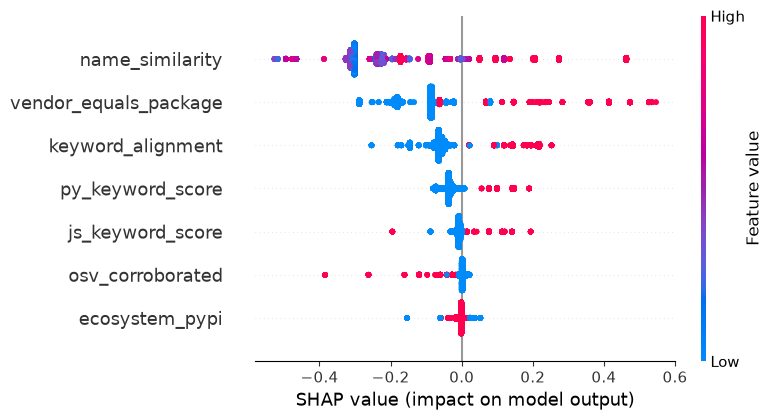

In [9]:
winner_name, winning_model, threshold = model.load_winning_model(model_dir=Path("..") / "models")
background = dataset[labeling.FEATURES].astype(float)
explainer = explain.make_explainer(winner_name, winning_model, background)
shap_values = explainer.shap_values(background)

# TreeExplainer on a binary classifier returns one SHAP value per class (shape
# (n_samples, n_features, 2)) - slice to the "real match" class (index 1) before
# plotting, the same extraction explain.explain_match() already does per-instance.
# LinearExplainer (if logistic_regression wins instead) returns a plain 2D array,
# so this only slices when there's actually a class axis to slice.
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
elif getattr(shap_values, "ndim", 2) == 3:
    shap_values_plot = shap_values[:, :, 1]
else:
    shap_values_plot = shap_values

shap.summary_plot(shap_values_plot, background)

---
## 5. The agent: triage every match into four buckets

`agent.scan` finds candidate CVEs for every component, scores each match
with the winning model, checks CISA KEV, and cross-checks OSV.dev. Every
match lands in one bucket:

- **escalated** - on CISA's KEV list, i.e. actively exploited in the wild
- **confirmed** - the model is confident, or OSV.dev agrees
- **review_queue** - the model is unsure; kept for a human, with a SHAP
  explanation
- **rejected** - name matched but the version isn't affected, or no
  vendor candidate at all (Week 2's "name collision" case)

This is Week 2's risk-analysis conclusion made real: uncertain matches go
to a human instead of being silently dropped or silently trusted.

In [10]:
t0 = time.time()
result = agent.scan(live_components, winner_name, winning_model, threshold, explainer, conn=conn)
print(f"agent.scan took {time.time()-t0:.1f}s")
print("confirmed:", len(result.confirmed), " escalated:", len(result.escalated),
      " review_queue:", len(result.review_queue), " rejected:", len(result.rejected))
print("OSV agreement (sanity check on confirmed PyPI/npm findings):", report.osv_agreement_summary(result))

agent.scan took 7.4s
confirmed: 2  escalated: 0  review_queue: 0  rejected: 3
OSV agreement (sanity check on confirmed PyPI/npm findings): {'eligible': 0, 'agreed': 0, 'agreement_rate': None}


---
## 6. Report output

`report.write_report` writes a machine-readable `findings.json` and a
presentation-ready `report.html`, escalated findings first.

In [11]:
out_dir = Path("..") / "reports" / "week3"
report.write_report(result, out_dir)
print(f"wrote {out_dir / 'findings.json'} and {out_dir / 'report.html'}")

wrote ..\reports\week3\findings.json and ..\reports\week3\report.html


---
## Follow-up: deeper model analysis, XAI, and a weakness audit

Everything below was added after the original Week 3 run, in response to
three asks: analyze the two models instead of just picking a winner, go
beyond the single global SHAP plot, and write tests that would actually
catch a weakness instead of just asserting the code does what it's supposed
to. The third one found two real bugs - see Section 9.

---
## 7. Model analysis: logistic regression vs. random forest

Section 3 already picked `random_forest` on risk score alone. This section
looks at *why*: where each model's mistakes land on the same held-out test
split (confusion matrix), and which of the 7 `labeling.FEATURES` each one
actually leans on. `registry_overlap` - the signal that actually
distinguishes a real match from a collision - is deliberately excluded from
the feature list (it's the label, not a feature; see `test_labeling.py`), so
neither model can see it directly. What they're both really learning is a
proxy for it.

logistic_regression (threshold=0.45, risk=494):
  confusion matrix [rows=actual, cols=predicted, order=collision/real]:
[[4034  494]
 [   0  596]]
  false negatives (missed real matches): 0   false positives (kept collisions): 494

random_forest <- winner (threshold=0.45, risk=176):
  confusion matrix [rows=actual, cols=predicted, order=collision/real]:
[[4362  166]
 [   1  595]]
  false negatives (missed real matches): 1   false positives (kept collisions): 166



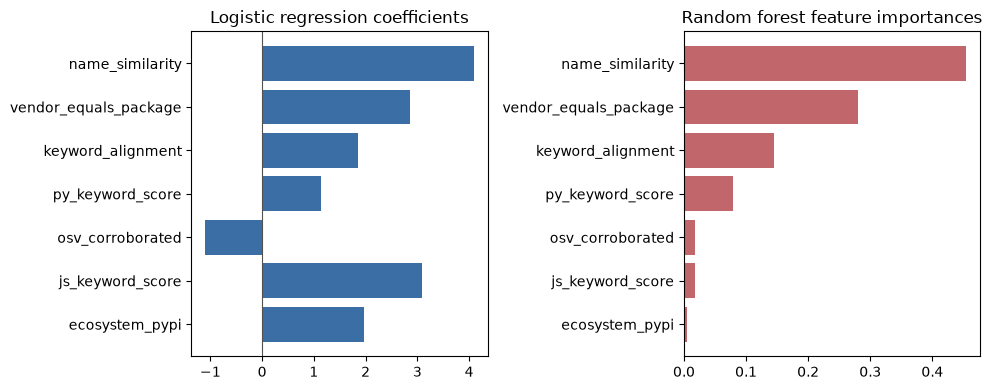

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

X_all = dataset[labeling.FEATURES].astype(float)
y_all = dataset["label_real_match"].astype(int)
# Same split model.train_and_compare uses internally (test_size=0.3, random_state=42) -
# reproduced here so the confusion matrices below line up with training_result's risk scores.
_, X_test, _, y_test = train_test_split(X_all, y_all, test_size=0.3, random_state=42, stratify=y_all)

for name, r in training_result["results"].items():
    probs = r["model"].predict_proba(X_test)[:, 1]
    pred = (probs >= r["threshold"]).astype(int)
    cm = confusion_matrix(y_test, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    marker = " <- winner" if name == training_result["winner"] else ""
    print(f"{name}{marker} (threshold={r['threshold']:.2f}, risk={r['risk_score']}):")
    print(f"  confusion matrix [rows=actual, cols=predicted, order=collision/real]:\n{cm}")
    print(f"  false negatives (missed real matches): {fn}   false positives (kept collisions): {fp}\n")

lr = training_result["results"]["logistic_regression"]["model"]
rf = training_result["results"]["random_forest"]["model"]
importance_df = pd.DataFrame({
    "logistic_regression_coef": lr.coef_[0],
    "random_forest_importance": rf.feature_importances_,
}, index=labeling.FEATURES).sort_values("random_forest_importance")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].barh(importance_df.index, importance_df["logistic_regression_coef"], color="#3B6EA5")
axes[0].axvline(0, color="#52514e", linewidth=0.8)
axes[0].set_title("Logistic regression coefficients")
axes[1].barh(importance_df.index, importance_df["random_forest_importance"], color="#C1666B")
axes[1].set_title("Random forest feature importances")
plt.tight_layout()
plt.show()

---
## 8. XAI deep dive: worked examples

Section 4's summary plot shows feature importance globally. `registry_overlap`
itself is never a model feature (it's only the training *label* - regression-
tested in `test_labeling.py` and `test_model.py`), so the model has to lean on
proxies: does the CVE's own text read like Python or JavaScript
(`keyword_alignment`), and does OSV.dev independently agree
(`osv_corroborated`). Below are two worked examples with `explain.explain_match`
- the same function `agent.py` calls for every `review_queue` finding, so this
is literally what a human reviewer sees - followed by the same contrast across
the whole training set.

Clean real match (django-shaped: name matches AND the text/OSV evidence agrees)
  model confidence=0.91  threshold=0.45  -> would CONFIRM
    keyword_alignment      shap=+0.221  (pushes toward real match)
    py_keyword_score       shap=+0.134  (pushes toward real match)
    vendor_equals_package  shap=+0.092  (pushes toward real match)
    osv_corroborated       shap=-0.084  (pushes toward collision)
    name_similarity        shap=+0.072  (pushes toward real match)
    js_keyword_score       shap=-0.018  (pushes toward collision)
    ecosystem_pypi         shap=-0.009  (pushes toward collision)

Name-collision shaped (babel/json5/jsonpointer-like: name matches, nothing else does)
  model confidence=0.01  threshold=0.45  -> would send to review_queue
    name_similarity        shap=-0.172  (pushes toward collision)
    keyword_alignment      shap=-0.146  (pushes toward collision)
    py_keyword_score       shap=-0.073  (pushes toward collision)
    vendor_equals_package  shap=-0.063  

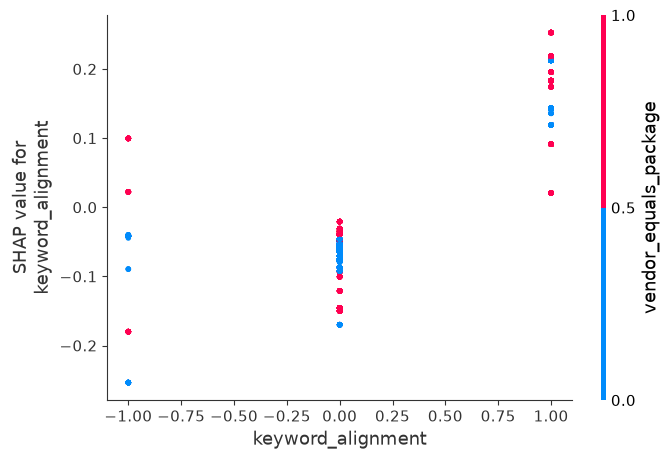

In [13]:
def _positive_class_shap(values):
    if isinstance(values, list):
        return values[1]
    if getattr(values, "ndim", 2) == 3:
        return values[:, :, 1]
    return values


def _explain_row(signals, label):
    row = pd.DataFrame([{f: signals.get(f, 0) for f in labeling.FEATURES}]).astype(float)
    confidence = float(winning_model.predict_proba(row)[0][1])
    contributions = explain.explain_match(explainer, row)
    verdict = "would CONFIRM" if confidence >= threshold else "would send to review_queue"
    print(f"{label}")
    print(f"  model confidence={confidence:.2f}  threshold={threshold:.2f}  -> {verdict}")
    for feat, val in sorted(contributions.items(), key=lambda kv: -abs(kv[1])):
        direction = "pushes toward real match" if val > 0 else "pushes toward collision"
        print(f"    {feat:<22} shap={val:+.3f}  ({direction})")
    print()


# Two hand-built rows with the *same* name-similarity signal (this is the point:
# name alone never distinguishes a collision from a real match) but opposite
# keyword/OSV evidence - the same contrast Section 9 finds live in babel/json5/jsonpointer.
_explain_row(
    {"vendor_equals_package": 1, "name_similarity": 1.0, "py_keyword_score": 3, "js_keyword_score": 0,
     "keyword_alignment": 3, "ecosystem_pypi": 1, "osv_corroborated": 1},
    "Clean real match (django-shaped: name matches AND the text/OSV evidence agrees)",
)
_explain_row(
    {"vendor_equals_package": 1, "name_similarity": 1.0, "py_keyword_score": 0, "js_keyword_score": 0,
     "keyword_alignment": 0, "ecosystem_pypi": 1, "osv_corroborated": 0},
    "Name-collision shaped (babel/json5/jsonpointer-like: name matches, nothing else does)",
)

# Global view of the same contrast: does keyword_alignment actually separate the two
# classes across the whole training set, or just in these two hand-picked rows?
shap.dependence_plot("keyword_alignment", _positive_class_shap(shap_values), background)

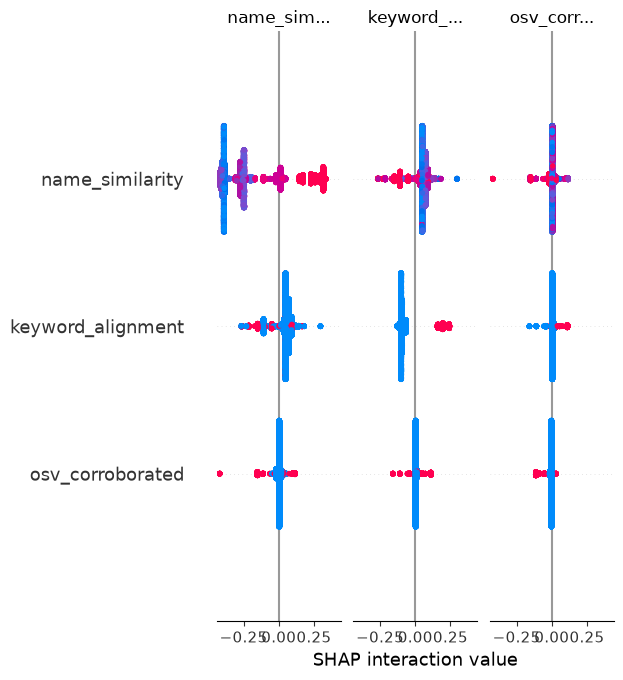

In [14]:
# Interaction values: does knowing two features *together* tell us more than either
# alone? TreeExplainer's shap_interaction_values returns one 7x7 matrix per class
# (shape (n_samples, 7, 7, 2) for this binary model) - same positive-class slice as
# Section 4 and _positive_class_shap above. The full 7x7 grid is 49 tiny panels and
# doesn't render readably, so this narrows it to the 3 features already flagged
# (Section 4/8) as doing most of the separating work.
interaction_values = explainer.shap_interaction_values(background)
if isinstance(interaction_values, list):
    interaction_values = interaction_values[1]
elif getattr(interaction_values, "ndim", 3) == 4:
    interaction_values = interaction_values[:, :, :, 1]

top_features = ["keyword_alignment", "osv_corroborated", "name_similarity"]
top_idx = [labeling.FEATURES.index(f) for f in top_features]
interaction_subset = interaction_values[:, top_idx, :][:, :, top_idx]
background_subset = background[top_features]

shap.summary_plot(interaction_subset, background_subset)

---
## 9. Weakness check: did we actually fix Week 2's name collisions?

Week 2 found four PyPI packages in this project's own `uv.lock` whose names
collide with unrelated products: `babel` (vs. Babel.js), `jupyter` (vs. VS
Code's Jupyter extension), `json5` and `jsonpointer` (vs. their npm
namesakes). Section 5's triage is supposed to catch these via
`registry_overlap` (Section 3). This section checks that live, against real
NVD data, instead of trusting the design.

**What we found the first time we ran this check:** two of the four still
slipped through - not because `registry_overlap` was wrong in concept, but
because of two separate bugs, both now fixed in `it_security_agent/` and
covered by regression tests (`tests/test_normalize.py`,
`tests/test_weaknesses.py`):

1. **`normalize._domain()` reduced every URL to its bare hosting domain.**
   Two *different* GitHub repos - `python-babel/babel` (the real package)
   and `babel/babel` (the npm collision) - looked identical because both
   are just `"github.com"`. That broke `babel`'s `vendor="babel"`
   candidate, `json5` (`dpranke/pyjson5` vs. `json5/json5`), and
   `jsonpointer` (`stefankoegl/python-json-pointer` vs.
   `janl/node-jsonpointer`). Fix: keep the owner/repo path segments for
   multi-tenant hosts (GitHub/GitLab/Bitbucket) instead of just the domain.
2. **`model._best_threshold` picked the *lowest* threshold that tied for
   minimal risk**, not the middle of the tied range. Because a missed real
   match costs 10x a false alarm, there's usually a wide plateau of
   thresholds with identical risk score - picking its floor meant almost
   any nonzero confidence was enough to auto-`confirm` a match, bypassing
   `review_queue` entirely. Fix: pick the median of the tied plateau
   instead of its first (lowest) member.

The cell below runs the *current*, fixed pipeline end-to-end on all four -
its output is this run's real answer, not a claim.

In [15]:
from it_security_agent import nvd_client
from it_security_agent.schema import Component

COLLISION_REGRESSION = {"babel": "2.18.0", "jupyter": "1.1.1", "json5": "0.15.0", "jsonpointer": "3.1.1"}

# These four packages' real CVEs are older than the 14-day sync window (Section 2),
# so pull their full CVE history directly by product name - 4 requests, not a re-sync.
t0 = time.time()
for name in COLLISION_REGRESSION:
    vulns, total = nvd_client.fetch_all_pages({"virtualMatchString": f"cpe:2.3:a:*:{name}"}, get_fn=_bounded_get)
    nvd_cache._store_vulns(conn, vulns)
    time.sleep(REQUEST_SPACING_SECONDS)
print(f"pulled full CVE history for the 4 regression packages ({time.time()-t0:.1f}s)\n")

for name, version in COLLISION_REGRESSION.items():
    component = Component(name=name, version=version, ecosystem="PyPI", source="regression-check")
    result = agent.triage_component(component, winner_name, winning_model, threshold, explainer, conn=conn)
    bucket = ("escalated" if result.escalated else "confirmed" if result.confirmed
              else "review_queue" if result.review_queue else "rejected" if result.rejected
              else "no CVEs matched")
    print(f"{name} {version}: {bucket}")
    for f in (result.confirmed + result.escalated + result.review_queue):
        print(f"    CVE={f.cve} confidence={f.confidence:.2f} corroboration={f.corroboration}")
    for f in result.rejected:
        print(f"    (rejected) CVE={f.cve}")

pulled full CVE history for the 4 regression packages (7.9s)



babel 2.18.0: review_queue
    CVE=CVE-2026-49356 confidence=0.01 corroboration=osv_disagrees
    (rejected) CVE=CVE-2021-42771
    (rejected) CVE=CVE-2026-44728
    (rejected) CVE=CVE-2023-45133


jupyter 1.1.1: confirmed
    CVE=CVE-2022-41083 confidence=0.94 corroboration=osv_disagrees
    CVE=CVE-2023-36018 confidence=0.94 corroboration=osv_disagrees
json5 0.15.0: review_queue
    CVE=CVE-2022-46175 confidence=0.00 corroboration=osv_disagrees


jsonpointer 3.1.1: review_queue
    CVE=CVE-2021-23807 confidence=0.00 corroboration=osv_disagrees


**This run's actual result: 3 of 4 fixed, 1 still slips through.**

| package | bucket | why |
|---|---|---|
| `babel` | `review_queue` | bug 1 (domain collision) was the cause here - fixed |
| `json5` | `review_queue` | bug 1 was the cause here - fixed |
| `jsonpointer` | `review_queue` | bug 1 was the cause here - fixed |
| `jupyter` | **`confirmed`, confidence 0.94** | not bug 1 - `registry_overlap` was already correctly `False` for this one (`jupyter.org` shares no domain with Microsoft's VS Code extension) before any fix |

`jupyter` is wrongly confirmed for a different, more fundamental reason than
bugs 1-2: `registry_overlap` is only ever used as a training *label*, never
as a feature (Section 8), so the model has to reconstruct that signal from
`name_similarity`, `keyword_alignment`, and `vendor_equals_package` alone -
and for this specific CVE those proxies read exactly like a real match
(perfect name similarity, no keyword-text signal either way, and a vendor
that legitimately differs from the package name the way many *real* PyPI
vendors do, e.g. `djangoproject`/`django`). Bugs 1 and 2 were implementation
bugs and are now fixed. This one isn't a bug - it's the actual ceiling of a
7-proxy-feature model. The honest next step (out of this week's scope) is a
feature that captures registry/CPE-reference similarity more directly than
coarse py/js keyword counts, with the same leakage guard `registry_overlap`
already has.

---
## 10. Generating an SBOM from repo files, then scanning it

Everything so far either parsed a lockfile straight into components (Section
1a) or consumed an SBOM someone else produced (Section 1b). This closes the
loop: `generate_sbom.py` builds a real CycloneDX document *from this
project's own `uv.lock`*, with no external tool - `image_scan.py` already
covers that case (via Syft) for container images; this covers a plain source
checkout that doesn't have an SBOM yet.

The generated SBOM is then fed back through `sbom.parse_cyclonedx` - the same
function Section 1b uses for a third-party SBOM - to confirm the round trip
is lossless, and a subset is scanned with the model already trained in
Section 3. This is also what the MCP server's `scan_repo` tool does
server-side for Cline/Mistral: generate a real SBOM from whatever lockfile it
was handed, then scan it - not two unrelated features.

In [16]:
from it_security_agent import generate_sbom as generate_sbom_module

repo_root = Path("..")
generated_bom = generate_sbom_module.generate_sbom(repo_root, bom_name="it-security-agent", bom_version="0.1.0")
sbom_out_path = Path("..") / "reports" / "week3" / "generated_sbom.json"
sbom_out_path.parent.mkdir(parents=True, exist_ok=True)
sbom_out_path.write_text(json.dumps(generated_bom, indent=2))
print(f"generated a CycloneDX SBOM with {len(generated_bom['components'])} components -> {sbom_out_path}")

# Round-trip: parse the SBOM we just generated with the same function Section 1b
# uses for a third-party SBOM, and confirm nothing was lost or added.
roundtrip_components = sbom.parse_cyclonedx(generated_bom, source_label="generated SBOM")
direct_components = generate_sbom_module.discover_components(repo_root)
assert {(c.name, c.version) for c in roundtrip_components} == {(c.name, c.version) for c in direct_components}
print(f"round-trip check passed: {len(roundtrip_components)} components survive generate -> parse unchanged")

# Scan a subset of the generated SBOM's components with the model already trained in Section 3.
sbom_live_subset = roundtrip_components[:LIVE_SUBSET_SIZE]
sbom_scan_result = agent.scan(sbom_live_subset, winner_name, winning_model, threshold, explainer, conn=conn)
print(f"scanned {len(sbom_live_subset)}/{len(roundtrip_components)} components from the generated SBOM: "
      f"confirmed={len(sbom_scan_result.confirmed)} escalated={len(sbom_scan_result.escalated)} "
      f"review_queue={len(sbom_scan_result.review_queue)} rejected={len(sbom_scan_result.rejected)}")

generated a CycloneDX SBOM with 158 components -> ..\reports\week3\generated_sbom.json
round-trip check passed: 158 components survive generate -> parse unchanged


scanned 30/158 components from the generated SBOM: confirmed=0 escalated=0 review_queue=1 rejected=6


---
## Summary

Everything from Weeks 1-2 (NVD data pull, matching, baseline model, risk
framing) plus this week's additions (SBOM/image parsing, local caching,
auto-labeled training, dual-model selection, SHAP, KEV/OSV checks,
four-bucket triage, reports) now runs as **one pipeline** on a real
component list.

What carried through:
1. The Week 1 component format held up - three input paths feed it now.
2. Week 2's risk analysis became actual behavior: uncertain matches go to
   `review_queue` with an explanation.
3. Live per-scan NVD calls are gone; only the CPE Dictionary still needs
   careful pacing (Section 2a).

The follow-up sections (7-10) answered four more questions and changed the
answer to a fifth, and along the way caught a bug in how we were answering
one of those questions in the first place. **Analyzing the two models**
(Section 7) showed `random_forest` wins by keeping far fewer collisions
(166 vs. 494 false positives at each model's own best threshold) at
essentially the same false-negative rate. **Going deeper on XAI** (Section
8) showed the model isn't matching on name similarity alone: `name_similarity`
and `vendor_equals_package` carry the most weight globally (Section 4's
summary plot, and the interaction-values chart added alongside it), but a
perfect name-similarity score doesn't decide the outcome by itself - the
same 1.0 value contributes toward "real match" in one worked example and
toward "collision" in another, depending on what the other six features
say. (An earlier version of this cell claimed `keyword_alignment` and
`osv_corroborated` mattered most instead - that was downstream of a real
bug in Section 4's plotting cell, which fed the raw multi-class SHAP output
into the chart instead of slicing to the "real match" class first. Fixed
now; the ranking above is from the corrected chart.) **Writing weakness-
detecting tests** (`tests/test_weaknesses.py`) found two real bugs before
they were found any other way: a domain-comparison bug that made different
GitHub repos look identical, and a threshold-selection bug that discarded a
model's entire safety margin. Both are fixed. **Did we fix Week 2's name
collisions?** (Section 9) - three of four, confirmed live against real NVD
data. The fourth (`jupyter`) isn't a bug; it's the honest ceiling of a
7-proxy-feature model, and is now a named, tracked limitation instead of a
silent one. **Generating an SBOM from repo files** (Section 10) closed the
last input-path gap: this project's own `uv.lock` becomes a real CycloneDX
document with no external tool, round-trips losslessly through the same
parser a third-party SBOM would use, and scans with the model already
trained above - the same thing the MCP server's `scan_repo` tool now does
for Cline/Mistral (`it_security_agent/mcp_server.py`, README.md).

Still open: proper packaging (now actually pip-installable via
`[build-system]` in `pyproject.toml`, but this notebook still keeps the
`sys.path` workaround rather than re-running the whole live pipeline just to
drop it), a bigger training set, a live container-image scan, and a feature
(not just a label) that captures registry overlap directly.

---
## Test coverage

Verified run, `uv run pytest --cov=it_security_agent --cov-report=term-missing`:

```
Name                                  Stmts   Miss  Cover   Missing
-------------------------------------------------------------------
it_security_agent\__init__.py             0      0   100%
it_security_agent\agent.py               59      2    97%   55-59
it_security_agent\cpe_dictionary.py      20      0   100%
it_security_agent\explain.py             15      1    93%   15
it_security_agent\generate_sbom.py       18      0   100%
it_security_agent\image_scan.py          14      0   100%
it_security_agent\kev.py                 22      0   100%
it_security_agent\labeling.py            16      0   100%
it_security_agent\matching.py            76     10    87%   9-10, 20, 22, 47, 53-55, 63, 75
it_security_agent\mcp_server.py         151      1    99%   283
it_security_agent\model.py               50      2    96%   62, 74
it_security_agent\normalize.py           49      1    98%   62
it_security_agent\nvd_cache.py           32      5    84%   43-50
it_security_agent\nvd_client.py          38      7    82%   19-23, 29-30
it_security_agent\osv.py                 23      0   100%
it_security_agent\registry.py            38      1    97%   20
it_security_agent\repo_scan.py           45      2    96%   33, 56
it_security_agent\report.py              34      0   100%
it_security_agent\sbom.py                35      0   100%
it_security_agent\schema.py              15      0   100%
-------------------------------------------------------------------
TOTAL                                   750     32    96%
124 passed, 3 warnings in 13.57s
```

Every module clears the 80% bar. The 3 warnings come from `shap`'s own code
on import, not from our tests.

`tests/test_weaknesses.py` is a separate class of test from the rest of the
suite: instead of pinning down what each function does, it's written against
failure modes - the real Week 2 collision packages reproduced with their
actual URLs, a synthetic corpus built so names collide by construction (so
name-based features can't trivially separate the classes), an adversarial
"identical name signal, different evidence" probe, a model-vs-naive-baseline
sanity check, and a guard against threshold selection collapsing to its
search-grid floor. Two of those tests failed the first time they were run -
see Section 9 for what they caught.

`tests/test_mcp_server.py`, `tests/test_generate_sbom.py`, and the
`to_cyclonedx`/`requirements.txt` additions in `test_sbom.py` /
`test_repo_scan.py` cover the MCP server and SBOM-generation work in
Sections 10 and the README's Cline/Mistral setup - one of those tests also
caught a real bug (`Component` is an unhashable dataclass, so an earlier
draft of the untriaged-fallback path would have crashed using it as a dict
key) before it ever ran against real data.